# Explorative Data Analysis
In this notebook, we perform a comprehensive audit of `customers.csv` and `orders.csv`. 
We will address missing values and outliers, and justify our cleaning strategy based on the feature distributions and the risk of introducing bias into downstream models.
Then, we will perform a descriptive analysis on observed trends from a customer perspective.

---
## Data Dictionary

Quick reference for every column in the two source files.

---

### `customers.csv`

| Column | Type | Description |
|--------|------|-------------|
| `Customer_ID` | string | Unique identifier for each customer |
| `Age` | integer | Customer age in years at the time of data collection |
| `Gender` | string | Customer gender (`F` = female, `M` = male) |
| `Privacy` | string | Whether the customer has given marketing consent (`Y` = yes, `N` = no) |
| `tenure` | float | Length of the customer relationship in years |
| `Region` | string | Italian region where the customer is registered |

---

### `orders.csv`

| Column | Type | Description |
|--------|------|-------------|
| `year` | integer | Calendar year in which the order was placed |
| `Customer_ID` | string | Unique identifier for each customer |
| `Order_Nr` | string | Unique order identifier |
| `Product_category` | string | Product category of the purchased item ( `Beauty` or `Electronics`) |
| `Quantity` | integer | Number of units purchased in the order |
| `Value` | float | Monetary value of the order in euros|


Import libraries and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
customers = pd.read_csv('customers.csv')
orders = pd.read_csv('orders.csv')

print("Customers shape:", customers.shape)
print("Orders shape:", orders.shape)

Customers shape: (65853, 6)
Orders shape: (146415, 6)


## 1. Comprehensive Audit of the Data
We will examine the variable types, missing values, duplicates, and basic descriptive statistics for both datasets.

In [2]:
print("--- Customers Dataset Info ---")
customers.info()
print("\nMissing values:\n", customers.isnull().sum())
print("\nDuplicates:", customers.duplicated().sum())

print("\n--- Orders Dataset Info ---")
orders.info()
print("\nMissing values:\n", orders.isnull().sum())
print("\nDuplicates:", orders.duplicated().sum())

--- Customers Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 65853 entries, 0 to 65852
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Customer_ID  65853 non-null  str  
 1   Age          65853 non-null  int64
 2   Gender       65853 non-null  str  
 3   Privacy      64097 non-null  str  
 4   tenure       65853 non-null  str  
 5   Region       64172 non-null  str  
dtypes: int64(1), str(5)
memory usage: 3.0 MB

Missing values:
 Customer_ID       0
Age               0
Gender            0
Privacy        1756
tenure            0
Region         1681
dtype: int64

Duplicates: 0

--- Orders Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 146415 entries, 0 to 146414
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   year              146415 non-null  int64  
 1   Customer_ID       146415 non-null  str    
 2   Order_Nr       

### Analysis of the Audit:
**Customers Dataset:**
- `Privacy` and `Region` columns have missing values.
- `tenure` is stored as an object, likely due to some non-numeric characters or just string formatting. It needs to be converted to numeric, which may reveal additional missing values.
- `Age` is numeric.

**Orders Dataset:**
- no missing data detected, all columns have the correct type

## 2. Addressing Missing Values and Outliers
First, let's cast incorrect data types to numeric to see if structural errors turn into missing values.

In [3]:
# Convert data types in customers
customers['tenure'] = pd.to_numeric(customers['tenure'], errors='coerce')

print("\nCustomers missing after type conversion:\n", customers.isnull().sum())


Customers missing after type conversion:
 Customer_ID       0
Age               0
Gender            0
Privacy        1756
tenure          916
Region         1681
dtype: int64


Next, let's look at the distributions of numeric features to identify outliers.

            Quantity          Value
count  146415.000000  146415.000000
mean        1.774948     147.912456
std         1.269726     146.967462
min         1.000000       0.000000
25%         1.000000      65.705990
50%         1.000000     106.582210
75%         2.000000     172.843190
max        35.000000    3953.748760


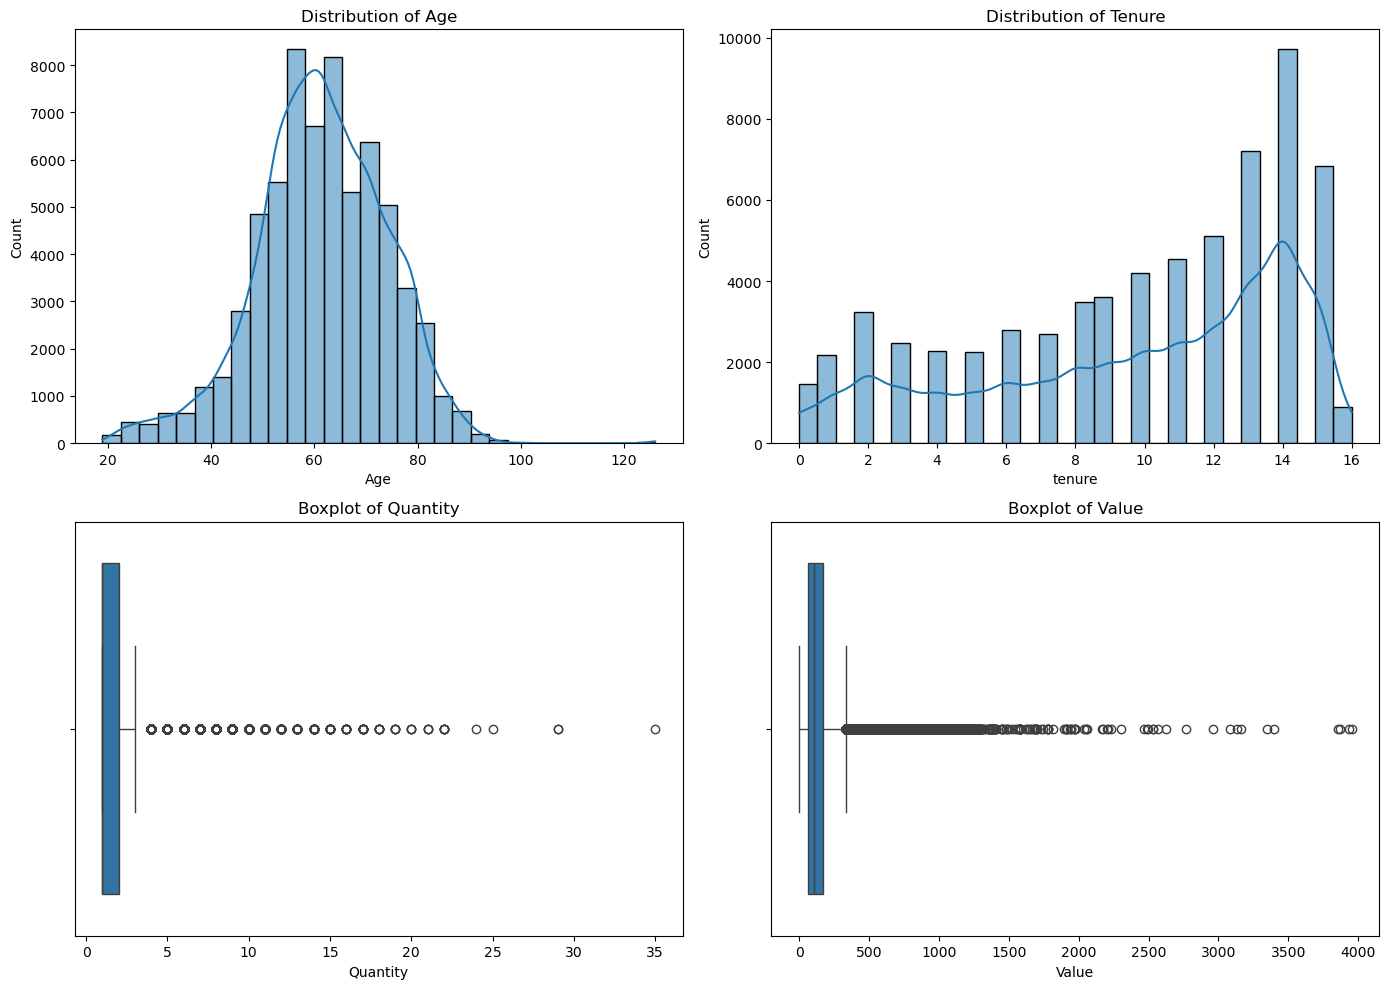

In [4]:
# Summary statistics for numerical features
cols_to_analyze = ['Quantity', 'Value']
print(orders[cols_to_analyze].describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(customers['Age'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Age')

sns.histplot(customers['tenure'].dropna(), bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Tenure')

sns.boxplot(x=orders['Quantity'], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot of Quantity')

sns.boxplot(x=orders['Value'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot of Value')

plt.tight_layout()
plt.show()

### Justification of Cleaning Strategy
1. **Missing Categorical Data (`Privacy`, `Region`)**: 
   - `Privacy` and `Region` have missing values. Imputing them with the mode might skew the distribution if the missingness is not entirely at random. A safer approach to avoid bias is to create a new category 'Unknown' for these missing values. This preserves the rows and signals to downstream models that the information was missing, potentially capturing predictive power associated with the missingness itself. We are going to do that for `Region`.
   For `Privacy` we are going to impute missing values with the value 'N' since we know that if we do not have the explicit consent of the customer we cannot contact them with marketing communications. 
2. **Missing Numeric Data (`tenure`)**:
   - `tenure` has missing values after correcting its type. We can use median imputation because it is robust to outliers, ensuring we don't skew the general customer profile. If we simply drop the rows, we might lose representation for certain cohorts, injecting survivorship bias.
3. **Outliers (`Age`, `Quantity`, `Value`)**:
   - For `Age`, capping to a reasonable limit (like 90) avoids our models overfitting to an absolute outlier, maintaining generalizability.
   - For `Quantity`, we will clip extreme outliers at the overall 99th percentile. For `Value`, since different product categories naturally have different price distributions, applying a global threshold might introduce category-level bias in downstream models. Therefore, we will calculate the 99th percentile threshold grouped by `Product_category` and clip extreme `Value` outliers within each category independently.


In [5]:
# Apply the Cleaning Strategy

# 1. Handle Missing Categorical
customers['Privacy'] = customers['Privacy'].fillna('N')
customers['Region'] = customers['Region'].fillna('Unknown')

# 2. Handle Missing Numeric
median_tenure = customers['tenure'].median()
customers['tenure'] = customers['tenure'].fillna(median_tenure)

# 3. Handle Outliers
# Capping Age at 90
customers['Age'] = customers['Age'].clip(upper=90)

# Cap extreme outliers at the 99th percentile for Quantity
q_quant = orders['Quantity'].quantile(0.99)
orders['Quantity'] = orders['Quantity'].clip(upper=q_quant)

# Cap extreme outliers at the 99th percentile for Value per Product_category
def cap_by_category(x):
    return x.clip(upper=x.quantile(0.99))

orders['Value'] = orders.groupby('Product_category')['Value'].transform(cap_by_category)

print("Cleaning complete. Let's verify:")
print("Customers missing:", customers.isnull().sum().sum())
print("Orders missing:", orders.isnull().sum().sum())

Cleaning complete. Let's verify:
Customers missing: 0
Orders missing: 0


Check of the variables after the cleaning:

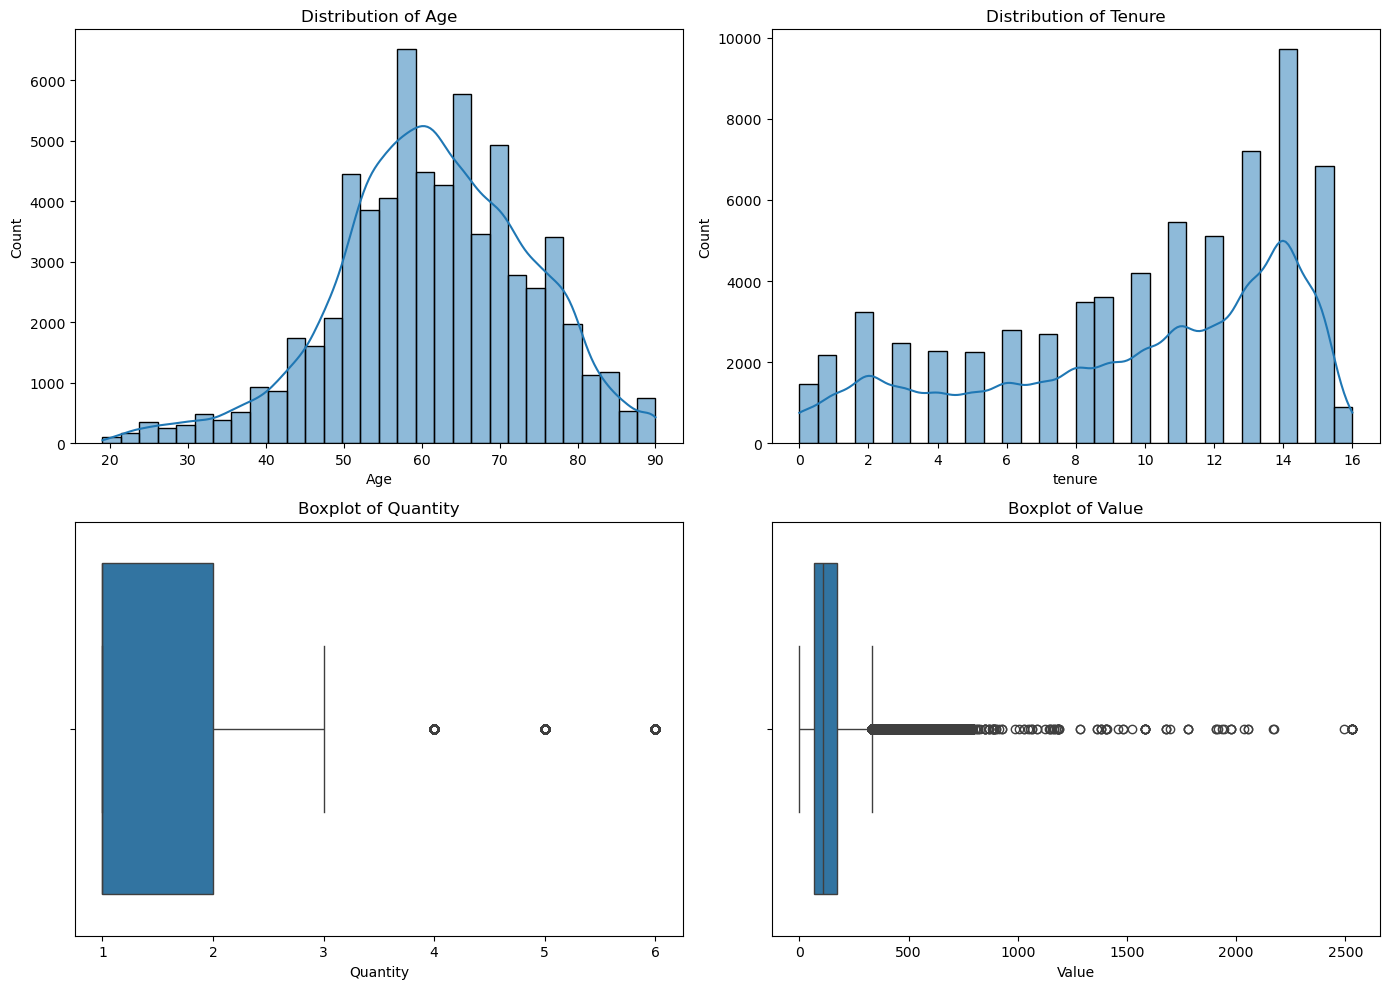

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(customers['Age'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Age')

sns.histplot(customers['tenure'].dropna(), bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Tenure')

sns.boxplot(x=orders['Quantity'], ax=axes[1, 0])
axes[1, 0].set_title('Boxplot of Quantity')

sns.boxplot(x=orders['Value'], ax=axes[1, 1])
axes[1, 1].set_title('Boxplot of Value')

plt.tight_layout()
plt.show()

In [7]:
# Summary statistics for numerical features
cols_to_analyze = ['Quantity', 'Value']
orders[cols_to_analyze].describe()

,Quantity,Value
count,146415.000000,146415.000000
mean,1.747854,146.028154
std,1.110457,134.548279
min,1.000000,0.000000
25%,1.000000,65.705990
50%,1.000000,106.582210
75%,2.000000,172.843190
max,6.000000,2531.671340


## 3. Data Merging and Refinement

Now that both datasets have been audited and cleaned, we merge them into a single coherent dataset.
We perform a **left join** on `Customer_ID`, keeping all order records and enriching them with customer information.

Additionally, we cast the `year` column to a **categorical** type so it is treated as a discrete time factor rather than a continuous numeric variable in downstream models. This prevents algorithms from interpreting 2024 as numerically 'double' of 1012, and allows the model to learn a separate effect for each year.

In [8]:
# Merge the two dataframes on Customer_ID using a LEFT join (keeping all orders)
merged_df = pd.merge(orders, customers, on='Customer_ID', how='left')

# Ensure the 'year' column is treated as a categorical / time factor
# Check for possible BOM-prefixed column name (common with some CSV exports)
year_col = next(
    (c for c in merged_df.columns if c.strip('\ufeff') == 'year'),
    None
)
if year_col is not None:
    if year_col != 'year':
        merged_df = merged_df.rename(columns={year_col: 'year'})
    merged_df['year'] = merged_df['year'].astype('category')

# Display the first 5 rows of the merged dataframe
print('Merged dataset shape:', merged_df.shape)
display(merged_df.head())


Merged dataset shape: (146415, 11)


,year,Customer_ID,Order_Nr,Product_category,Quantity,Value,Age,Gender,Privacy,tenure,Region
0,2024,A89996572,I133144425,Beauty,2,88.00211,78,F,Y,14.0,Marche
1,2024,A89996572,I133155840,Beauty,3,233.65079,78,F,Y,14.0,Marche
2,2024,A89996572,I133223693,Beauty,1,71.01459,78,F,Y,14.0,Marche
3,2024,A89996572,I133249311,Beauty,3,102.43185,78,F,Y,14.0,Marche
4,2024,A89996605,I133249113,Beauty,4,310.19115,76,F,Y,14.0,Emilia-Romagna


## 4. Yearly Customer Behavior KPIs

Using the merged dataframe, we compute a summary table grouped by **year** to track key customer behavior indicators over time:

| KPI | Definition |
|-----|------------|
| **Total Revenue** | Sum of `Value` |
| **Active Customers** | Count of unique `Customer_ID` |
| **Total Orders** | Count of unique `Order_Nr` |
| **Total Quantity** | Sum of `Quantity` |
| **Order Frequency** | Total Orders / Active Customers |
| **AOV** | Total Revenue / Total Orders |
| **Avg Spending / Customer** | Total Revenue / Active Customers |
| **Units / Customer** | Total Quantity / Active Customers |
| **Avg Price** | Total Revenue / Total Quantity |
| **Retention Rate** | % of customers from the previous year who also purchased in the current year |

In [9]:
# ── Yearly KPI Summary ──────────────────────────────────────────────────────

# Ensure year is present as a plain integer for sorting/retention look-back
merged_df['year_int'] = merged_df['year'].cat.codes.map(
    dict(enumerate(sorted(merged_df['year'].cat.categories)))
)

# Base aggregations grouped by year
summary = (
    merged_df
    .groupby('year_int', sort=True)
    .agg(
        Total_Revenue    = ('Value',       'sum'),
        Active_Customers = ('Customer_ID', 'nunique'),
        Total_Orders     = ('Order_Nr',    'nunique'),
        Total_Quantity   = ('Quantity',    'sum'),
    )
    .reset_index()
    .rename(columns={'year_int': 'year'})
)

# Derived KPIs
summary['Order_Frequency']     = summary['Total_Orders']     / summary['Active_Customers']
summary['AOV']                 = summary['Total_Revenue']    / summary['Total_Orders']
summary['Avg_Spending']        = summary['Total_Revenue']    / summary['Active_Customers']
summary['Units_per_Customer']  = summary['Total_Quantity']   / summary['Active_Customers']
summary['Avg_Price']           = summary['Total_Revenue']    / summary['Total_Quantity']

# Retention Rate ─ % of customers from the previous year who returned
# Build per-year customer sets
year_customers = (
    merged_df
    .groupby('year_int')['Customer_ID']
    .apply(set)
    .to_dict()
)

sorted_years = sorted(year_customers.keys())

retention_rates = {}
for i, yr in enumerate(sorted_years):
    if i == 0:
        retention_rates[yr] = float('nan')   # no previous year
    else:
        prev_yr  = sorted_years[i - 1]
        prev_set = year_customers[prev_yr]
        curr_set = year_customers[yr]
        retained = len(prev_set & curr_set)
        retention_rates[yr] = round(retained / len(prev_set) * 100, 2) if prev_set else float('nan')

summary['Retention_Rate_pct'] = summary['year'].map(retention_rates)

# Display
pd.set_option('display.float_format', '{:,.2f}'.format)
display(summary.set_index('year'))


,Total_Revenue,Active_Customers,Total_Orders,Total_Quantity,Order_Frequency,AOV,Avg_Spending,Units_per_Customer,Avg_Price,Retention_Rate_pct
year,,,,,,,,,,
2024,"7,710,026.38",33940,50630,92373,1.49,152.28,227.17,2.72,83.47,NaN
2025,"7,353,523.37",32745,50728,87764,1.55,144.96,224.57,2.68,83.79,39.73
2026,"6,317,162.45",29204,44832,75775,1.54,140.91,216.31,2.59,83.37,39.00


## 5. Performance Breakdown

Examples of deep dives we could perform on this data:

Three analyses:
1. **Total Revenue by Region** – bar chart for the most recent year.
2. **Top-selling Product Category** – ranked by Quantity and by Value, one table per year.
3. **Top 10 % Customers by Spend** – demographic profile (avg age, top regions).

### 5.1 Total Revenue per Region – last available year

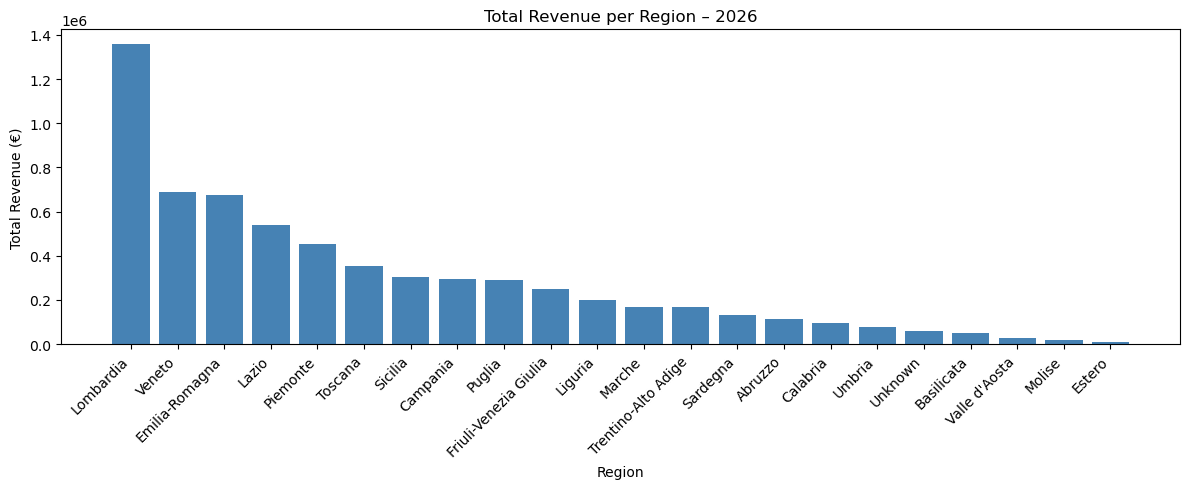

,Region,Total_Revenue
0,Lombardia,"1,357,162.46"
1,Veneto,"687,662.99"
2,Emilia-Romagna,"675,898.22"
3,Lazio,"539,833.01"
4,Piemonte,"452,542.44"
5,Toscana,"355,164.93"
6,Sicilia,"304,529.24"
7,Campania,"296,261.55"
8,Puglia,"289,071.56"
9,Friuli-Venezia Giulia,"247,935.48"


In [10]:
# Determine the last available year from the merged dataframe
last_year = merged_df['year_int'].max()

df_last = merged_df[merged_df['year_int'] == last_year]

revenue_by_region = (
    df_last
    .groupby('Region')['Value']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
revenue_by_region.columns = ['Region', 'Total_Revenue']

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(revenue_by_region['Region'], revenue_by_region['Total_Revenue'], color='steelblue')
ax.set_title(f'Total Revenue per Region – {last_year}')
ax.set_xlabel('Region')
ax.set_ylabel('Total Revenue (€)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(revenue_by_region)


### 5.2 Top-selling Product Category by Year

In [11]:
# Aggregate by year and product category
cat_year = (
    merged_df
    .groupby(['year_int', 'Product_category'])
    .agg(
        Total_Quantity = ('Quantity', 'sum'),
        Total_Value    = ('Value',    'sum'),
    )
    .reset_index()
)

# Rank within each year
cat_year['Rank_Qty']   = cat_year.groupby('year_int')['Total_Quantity'].rank(ascending=False, method='min').astype(int)
cat_year['Rank_Value'] = cat_year.groupby('year_int')['Total_Value'].rank(ascending=False, method='min').astype(int)

# Top category by Quantity per year
top_by_qty = (
    cat_year[cat_year['Rank_Qty'] == 1]
    [['year_int', 'Product_category', 'Total_Quantity']]
    .sort_values('year_int')
    .rename(columns={'year_int': 'Year', 'Product_category': 'Top Category (Qty)', 'Total_Quantity': 'Quantity'})
)

# Top category by Value per year
top_by_val = (
    cat_year[cat_year['Rank_Value'] == 1]
    [['year_int', 'Product_category', 'Total_Value']]
    .sort_values('year_int')
    .rename(columns={'year_int': 'Year', 'Product_category': 'Top Category (Value)', 'Total_Value': 'Value (€)'})
)

print('=== Top-selling category by QUANTITY per year ===')
display(top_by_qty.set_index('Year'))

print('\n=== Top-selling category by VALUE per year ===')
display(top_by_val.set_index('Year'))

print('\n=== Full ranking (all years) ===')
display(
    cat_year
    .sort_values(['year_int', 'Rank_Qty'])
    .rename(columns={'year_int': 'Year'})
    .set_index(['Year', 'Product_category'])
)


=== Top-selling category by QUANTITY per year ===


,Top Category (Qty),Quantity
Year,,
2024,Beauty,91917
2025,Beauty,87205
2026,Beauty,75672



=== Top-selling category by VALUE per year ===


,Top Category (Value),Value (€)
Year,,
2024,Beauty,"7,541,819.12"
2025,Beauty,"7,252,816.31"
2026,Beauty,"6,308,551.01"



=== Full ranking (all years) ===


Total_Quantity  Total_Value  Rank_Qty  Rank_Value
Year Product_category                                                   
2024 Beauty                     91917 7,541,819.12         1           1
     Electronics                  456   168,207.26         2           2
2025 Beauty                     87205 7,252,816.31         1           1
     Electronics                  559   100,707.06         2           2
2026 Beauty                     75672 6,308,551.01         1           1
     Electronics                  103     8,611.44         2           2

### 5.3 Top 10 % Customers by Total Spend – Demographic Profile

We identify customers whose **total spend** (summed across all years) falls in the **top 10 %** of the distribution.
Then we compare their demographic profile (average age, top regions) against the rest of the customer base.

Spend threshold (90th pct): 789.17 €
Top-10% customers : 6,819  (10.4% of all customers)
Remaining customers: 59,034

=== Average Age ===
  Top 10%  : 61.3 years
  Rest     : 61.4 years


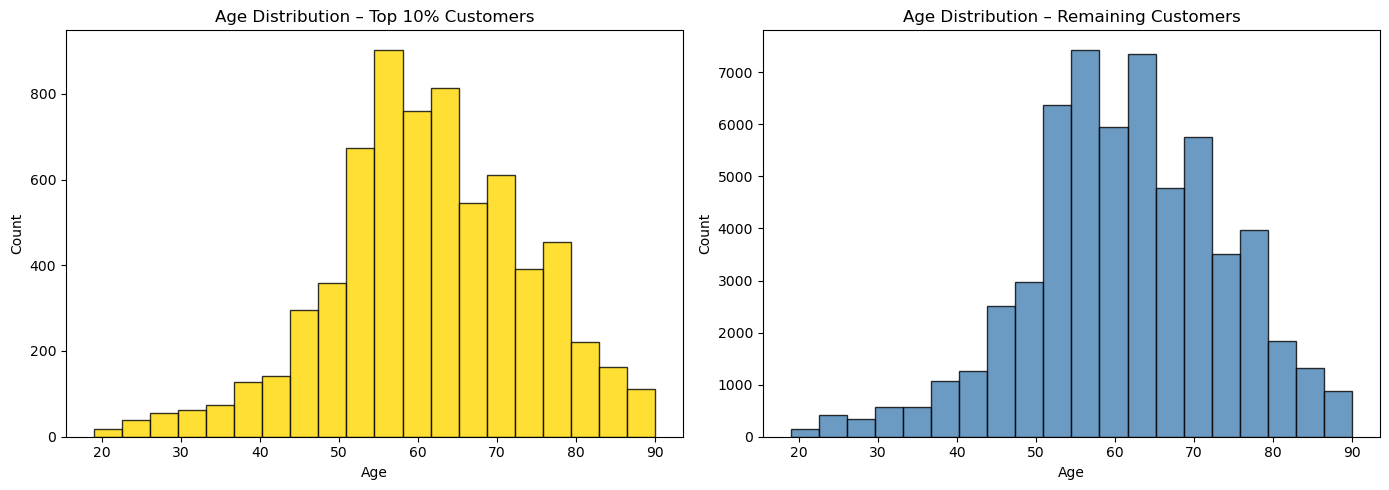


=== Top Regions – Top 10% Customers (% of segment) ===


,Share_pct
Region,
Lombardia,20.60
Emilia-Romagna,10.88
Veneto,10.53
Lazio,8.65
Piemonte,7.29
Toscana,5.56
Puglia,4.77
Sicilia,4.77
Campania,4.62



=== Top Regions – Remaining Customers (% of segment) ===


,Share_pct
Region,
Lombardia,20.66
Veneto,10.79
Emilia-Romagna,9.67
Lazio,8.48
Piemonte,7.12
Toscana,5.47
Campania,5.13
Sicilia,5.07
Puglia,4.76


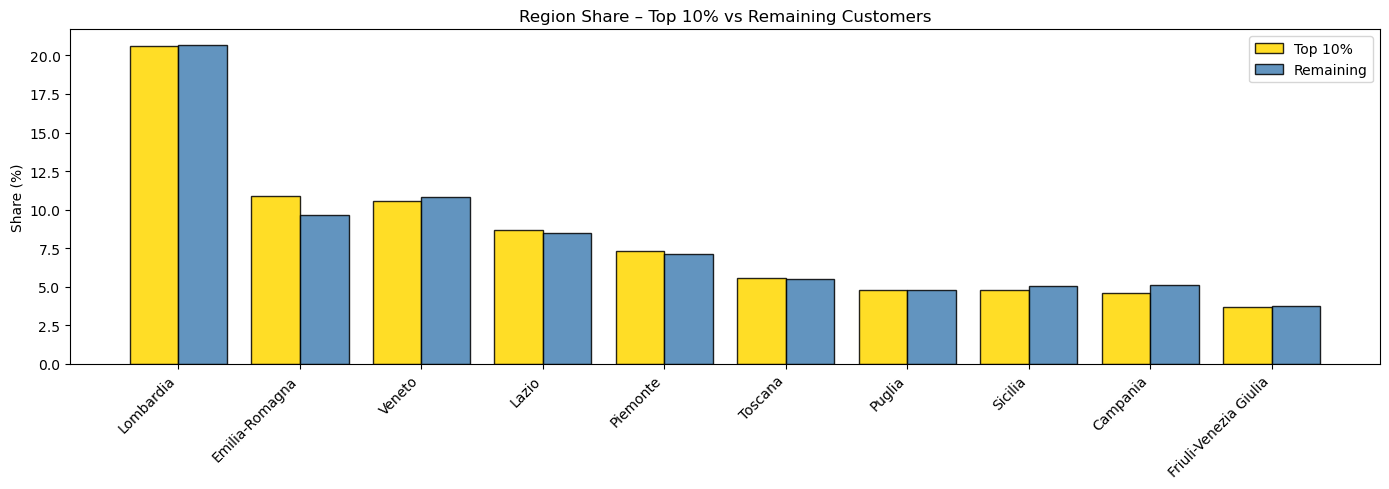

In [12]:
# Total spend per customer (all years)
spend_per_customer = (
    merged_df
    .groupby('Customer_ID')
    .agg(
        Total_Spend = ('Value', 'sum'),
        Age         = ('Age',   'first'),   # Age is fixed per customer
        Region      = ('Region','first'),   # idem
    )
    .reset_index()
)

# Threshold: 90th percentile of total spend
threshold = spend_per_customer['Total_Spend'].quantile(0.90)

top10 = spend_per_customer[spend_per_customer['Total_Spend'] >= threshold].copy()
rest  = spend_per_customer[spend_per_customer['Total_Spend'] <  threshold].copy()

print(f'Spend threshold (90th pct): {threshold:,.2f} €')
print(f'Top-10% customers : {len(top10):,}  ({len(top10)/len(spend_per_customer)*100:.1f}% of all customers)')
print(f'Remaining customers: {len(rest):,}')

# ── Average age comparison
print('\n=== Average Age ===')
print(f"  Top 10%  : {top10['Age'].mean():.1f} years")
print(f"  Rest     : {rest['Age'].mean():.1f} years")

# ── Age distribution side-by-side histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(top10['Age'], bins=20, color='gold',      edgecolor='black', alpha=0.8)
axes[0].set_title('Age Distribution – Top 10% Customers')
axes[0].set_xlabel('Age');  axes[0].set_ylabel('Count')

axes[1].hist(rest['Age'],  bins=20, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_title('Age Distribution – Remaining Customers')
axes[1].set_xlabel('Age');  axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# ── Top Regions
top10_regions = (
    top10['Region']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis('Region')
    .reset_index()
)
top10_regions.columns = ['Region', 'Share_pct']

rest_regions = (
    rest['Region']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis('Region')
    .reset_index()
)
rest_regions.columns = ['Region', 'Share_pct']

print('\n=== Top Regions – Top 10% Customers (% of segment) ===')
display(top10_regions.head(10).set_index('Region'))

print('\n=== Top Regions – Remaining Customers (% of segment) ===')
display(rest_regions.head(10).set_index('Region'))

# ── Bar chart: top regions comparison
n_regions = 10
top10_r = top10_regions.head(n_regions).set_index('Region')
rest_r  = rest_regions.head(n_regions).set_index('Region')
all_regions = list(dict.fromkeys(list(top10_r.index) + list(rest_r.index)))  # preserve order

x = range(len(all_regions))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar([i - width/2 for i in x], [top10_r['Share_pct'].get(r, 0) for r in all_regions],
       width=width, label='Top 10%',    color='gold',      edgecolor='black', alpha=0.85)
ax.bar([i + width/2 for i in x], [rest_r['Share_pct'].get(r, 0)  for r in all_regions],
       width=width, label='Remaining',  color='steelblue', edgecolor='black', alpha=0.85)
ax.set_xticks(list(x))
ax.set_xticklabels(all_regions, rotation=45, ha='right')
ax.set_title('Region Share – Top 10% vs Remaining Customers')
ax.set_ylabel('Share (%)')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Visualizations

Three charts built with **Seaborn / Matplotlib**:
1. **Dual-axis line chart** – Active Customers vs. Total Revenue over the years.
2. **Boxplot** – Customer Age distribution per year (is the target audience shifting?).
3. **Heatmap** – Pearson correlation between `tenure`, `Age`, and `Value`.

### 6.1 Active Customers vs. Total Revenue – trend over the years

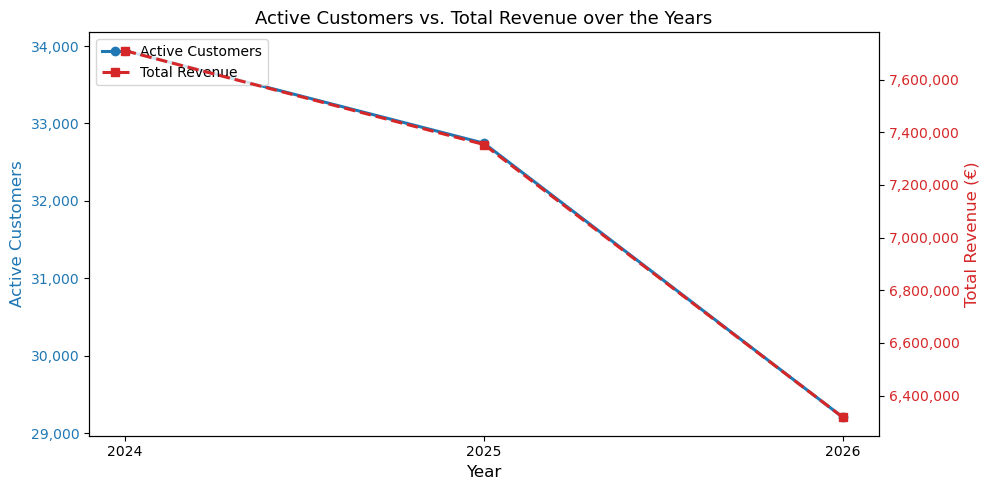

In [13]:
# Re-use the KPI summary computed in Section 4
# (summary dataframe with columns: year, Total_Revenue, Active_Customers, …)

fig, ax1 = plt.subplots(figsize=(10, 5))

color_customers = '#1f77b4'   # blue
color_revenue   = '#d62728'   # red

years = summary['year'].astype(str)

# Left axis – Active Customers
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Active Customers', color=color_customers, fontsize=12)
ax1.plot(years, summary['Active_Customers'],
         marker='o', linewidth=2.2, color=color_customers, label='Active Customers')
ax1.tick_params(axis='y', labelcolor=color_customers)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right axis – Total Revenue
ax2 = ax1.twinx()
ax2.set_ylabel('Total Revenue (€)', color=color_revenue, fontsize=12)
ax2.plot(years, summary['Total_Revenue'],
         marker='s', linewidth=2.2, linestyle='--', color=color_revenue, label='Total Revenue')
ax2.tick_params(axis='y', labelcolor=color_revenue)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.title('Active Customers vs. Total Revenue over the Years', fontsize=13)
plt.tight_layout()
plt.show()


### 6.2 Customer Age Distribution per Year

Each box shows the spread of **individual Age values** recorded in that year (one row per order, so active customers may appear multiple times – we deduplicate to one record per customer × year).

/var/folders/rp/vldf0xqd7rz1kcxdp15y37bm0000gp/T/ipykernel_30040/3512126452.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


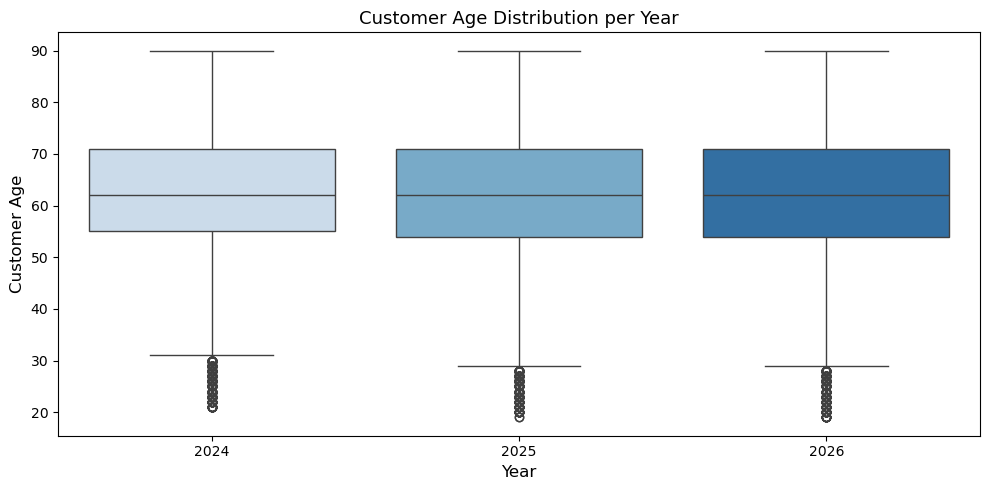

In [14]:
# Keep one record per customer per year to avoid over-counting repeated orders
age_per_year = (
    merged_df
    .drop_duplicates(subset=['year_int', 'Customer_ID'])
    [['year_int', 'Age']]
    .dropna(subset=['Age'])
    .copy()
)
age_per_year['year_int'] = age_per_year['year_int'].astype(str)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=age_per_year,
    x='year_int', y='Age',
    palette='Blues',
    order=sorted(age_per_year['year_int'].unique()),
    ax=ax
)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Customer Age', fontsize=12)
ax.set_title('Customer Age Distribution per Year', fontsize=13)
plt.tight_layout()
plt.show()


### 6.3 Correlation Heatmap – tenure, Age, Value

We compute the **Pearson correlation** among three numeric features present in the merged dataset:
- `tenure` – customer tenure (months / years as stored)
- `Age` – customer age
- `Value` – order value

Because every row is an order (not a customer), we first aggregate to one row per customer before computing the correlation matrix, so that repeated orders don't inflate the sample size and skew the correlation estimates.

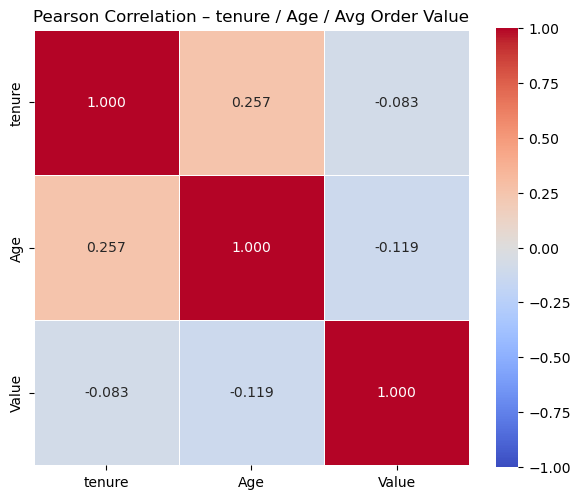


Correlation matrix:


,tenure,Age,Value
tenure,1.00,0.26,-0.08
Age,0.26,1.00,-0.12
Value,-0.08,-0.12,1.00


In [15]:
# Aggregate to one row per customer: fixed attributes + mean order value
customer_profile = (
    merged_df
    .groupby('Customer_ID')
    .agg(
        tenure = ('tenure', 'first'),
        Age    = ('Age',    'first'),
        Value  = ('Value',  'mean'),   # avg order value per customer
    )
    .reset_index(drop=True)
    .dropna(subset=['tenure', 'Age', 'Value'])
)

corr_matrix = customer_profile[['tenure', 'Age', 'Value']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Pearson Correlation – tenure / Age / Avg Order Value', fontsize=12)
plt.tight_layout()
plt.show()

print('\nCorrelation matrix:')
display(corr_matrix.round(3))
